In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

### Завантаження та обробка даних

In [5]:
# Завантаження набору даних CIFAR-10 (зображення 32x32)
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Попередня обробка: нормалізація пікселів (значення від 0 до 1)
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Категоризація міток (One-hot encoding)
y_train_full = tf.keras.utils.to_categorical(y_train_full, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Розбиття на навчальну та валідаційну вибірки (80% / 20%)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"Розмір навчальної вибірки: {x_train.shape}")
print(f"Розмір валідаційної вибірки: {x_val.shape}")
print(f"Розмір тестової вибірки: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step
Розмір навчальної вибірки: (40000, 32, 32, 3)
Розмір валідаційної вибірки: (10000, 32, 32, 3)
Розмір тестової вибірки: (10000, 32, 32, 3)


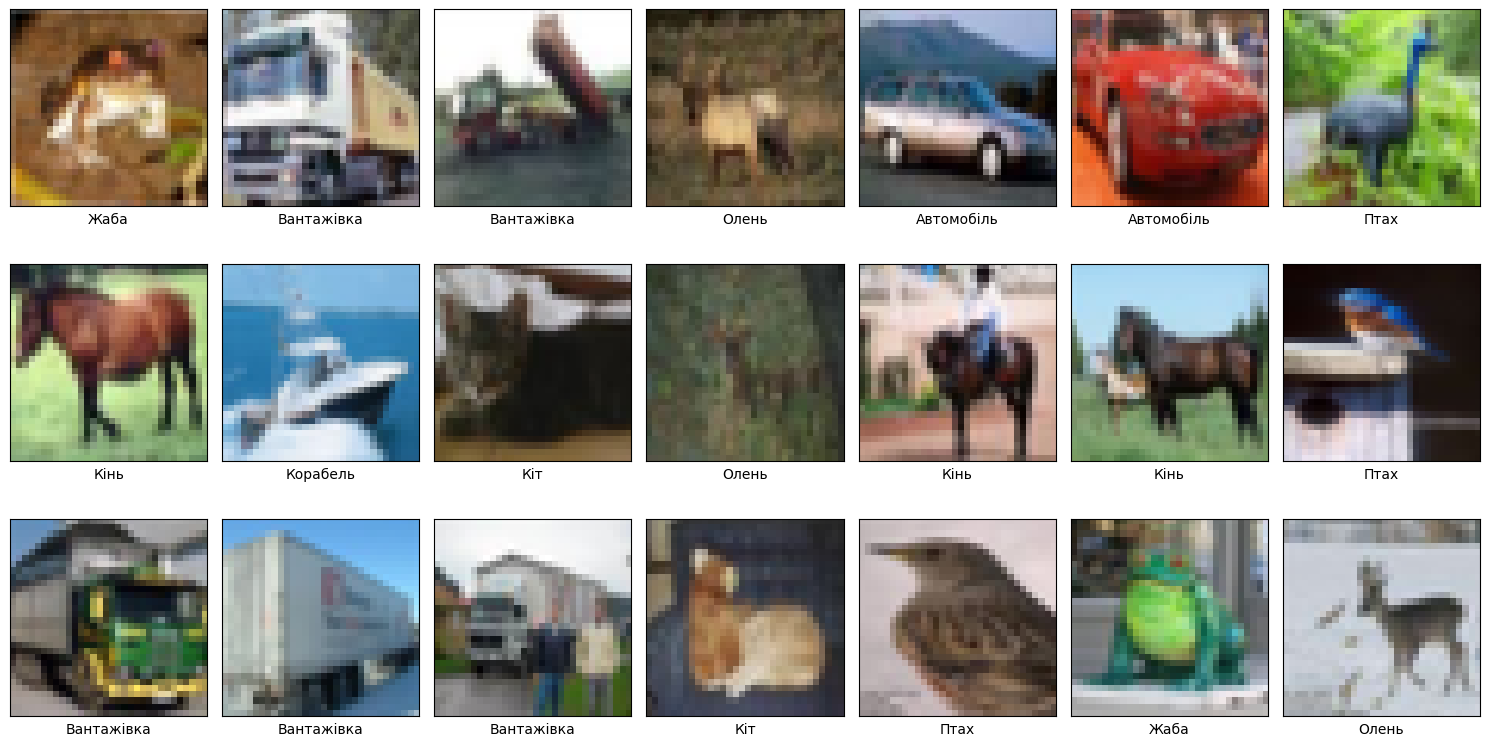

In [20]:
# Офіційні назви класів у датасеті CIFAR-10
class_names = ['Літак', 'Автомобіль', 'Птах', 'Кіт', 'Олень', 
               'Собака', 'Жаба', 'Кінь', 'Корабель', 'Вантажівка']

# Змінюємо розмір фігури для 21 зображення (3 рядки по 7 колонок)
plt.figure(figsize=(15, 8))

# Цикл на 21 ітерацію
for i in range(21):
    # Параметри subplot: 3 рядки, 7 колонок, індекс поточної картинки
    plt.subplot(3, 7, i + 1)
    plt.xticks([]) 
    plt.yticks([]) 
    plt.grid(False)
    
    # Виводимо зображення
    plt.imshow(x_train_full[i])
    
    # Визначаємо індекс класу через argmax
    label_index = np.argmax(y_train_full[i])
    
    # Підписуємо назву класу
    plt.xlabel(class_names[label_index], fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
def train_and_evaluate(model, model_name, epochs=10, batch_size=64):
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    start_time = time.time()
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, 
                        validation_data=(x_val, y_val), verbose=1)
    end_time = time.time()
    
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    training_time = end_time - start_time
    print(f"\n--- {model_name} ---")
    print(f"Час навчання: {training_time:.2f} секунд")
    print(f"Точність на тестовій вибірці: {test_acc:.4f}")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    plt.show()
    
    return test_acc, training_time

### Baseline

Тренування базової моделі...


/home/stella/.pyenv/versions/3.9.13/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-04 14:56:13.085295: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,410 (1.76 MB)

 Trainable params: 462,410 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3594 - loss: 1.7872 - val_accuracy: 0.5165 - val_loss: 1.3586
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5349 - loss: 1.3108 - val_accuracy: 0.5565 - val_loss: 1.2517
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5854 - loss: 1.1969 - val_accuracy: 0.5796 - val_loss: 1.2028
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6098 - loss: 1.1086 - val_accuracy: 0.6015 - val_loss: 1.1349
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6365 - loss: 1.0453 - val_accuracy: 0.6033 - val_loss: 1.1493
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6541 - loss: 1.0009 - val_accuracy: 0.6216 - val_loss: 1.0867
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6673 - loss: 0.9579 - val_accuracy: 0.6285 - val_loss: 1.0788
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6753 - loss: 0.9282 - 

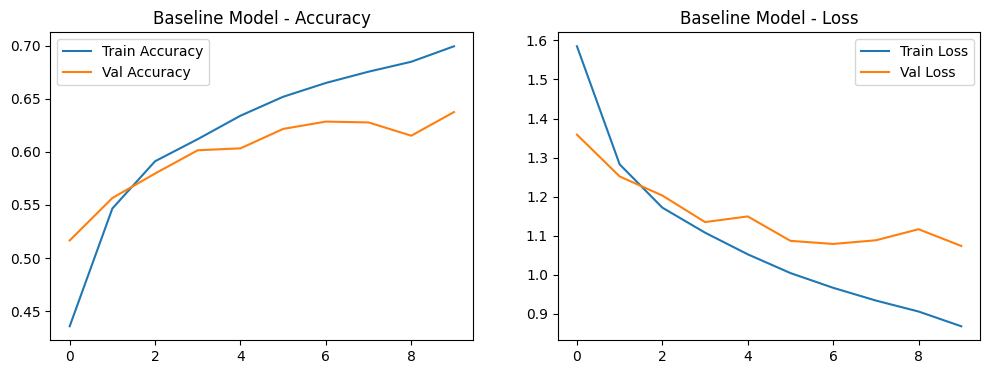

In [ ]:
print("Тренування базової моделі...")
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.summary()
acc_base, time_base = train_and_evaluate(baseline_model, "Baseline Model")

### Експеримент 1: Збільшуємо кількість фільтрів з 32 до 64 у згортковому шарі

Тренування Експерименту 1...


/home/stella/.pyenv/versions/3.9.13/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 924,106 (3.53 MB)

 Trainable params: 924,106 (3.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.3608 - loss: 1.7781 - val_accuracy: 0.5394 - val_loss: 1.3282
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5575 - loss: 1.2494 - val_accuracy: 0.5644 - val_loss: 1.2561
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.6055 - loss: 1.1322 - val_accuracy: 0.5899 - val_loss: 1.1857
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.6413 - loss: 1.0291 - val_accuracy: 0.6157 - val_loss: 1.1007
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.6707 - loss: 0.9512 - val_accuracy: 0.6326 - val_loss: 1.0573
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6941 - loss: 0.8850 - val_accuracy: 0.6353 - val_loss: 1.0655
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.7088 - loss: 0.8333 - val_accuracy: 0.6487 - val_loss: 1.0301
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.7230 - loss: 0.7944 - 

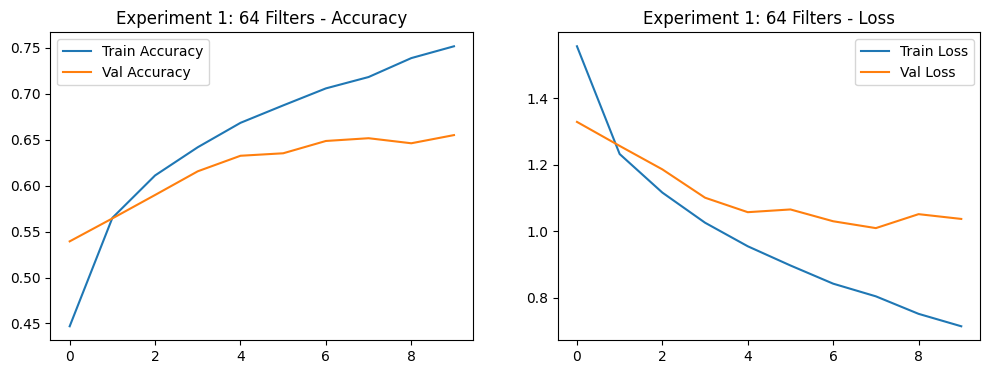

In [15]:
exp1_model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

exp1_model.summary()
acc_exp1, time_exp1 = train_and_evaluate(exp1_model, "Experiment 1: 64 Filters")

### Експеримент 2: Додавання Dropout перед вихідним шаром

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,410 (1.76 MB)

 Trainable params: 462,410 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.2004 - loss: 2.0980 - val_accuracy: 0.3897 - val_loss: 1.6719
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3004 - loss: 1.7933 - val_accuracy: 0.4568 - val_loss: 1.5358
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.3494 - loss: 1.6931 - val_accuracy: 0.4834 - val_loss: 1.4784
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.3801 - loss: 1.6336 - val_accuracy: 0.5161 - val_loss: 1.4002
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.3922 - loss: 1.5975 - val_accuracy: 0.5297 - val_loss: 1.3961
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4025 - loss: 1.5620 - val_accuracy: 0.5364 - val_loss: 1.3698
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4195 - loss: 1.5404 - val_accuracy: 0.5488 - val_loss: 1.3253
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4280 - loss: 1.5117 - 

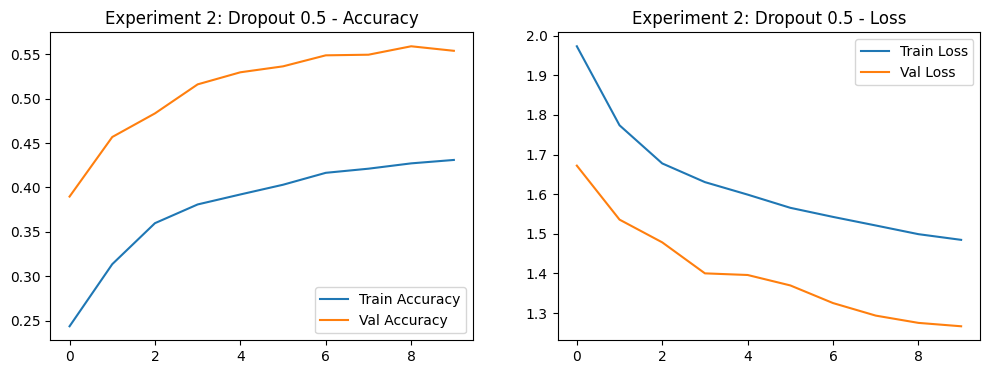

In [ ]:
exp2_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

exp2_model.summary()
acc_exp2, time_exp2 = train_and_evaluate(exp2_model, "Experiment 2: Dropout 0.5")

### Експеримент 3: Робимо мережу глибшою (додано Conv2D + MaxPooling)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.2888 - loss: 1.8980 - val_accuracy: 0.5061 - val_loss: 1.3915
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.5192 - loss: 1.3392 - val_accuracy: 0.5709 - val_loss: 1.2225
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5850 - loss: 1.1712 - val_accuracy: 0.6043 - val_loss: 1.1252
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6304 - loss: 1.0666 - val_accuracy: 0.6049 - val_loss: 1.1144
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6431 - loss: 1.0071 - val_accuracy: 0.6502 - val_loss: 1.0095
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.6678 - loss: 0.9489 - val_accuracy: 0.6538 - val_loss: 0.9953
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.6837 - loss: 0.9116 - val_accuracy: 0.6611 - val_loss: 0.9701
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.7054 - loss: 0.8525 - 

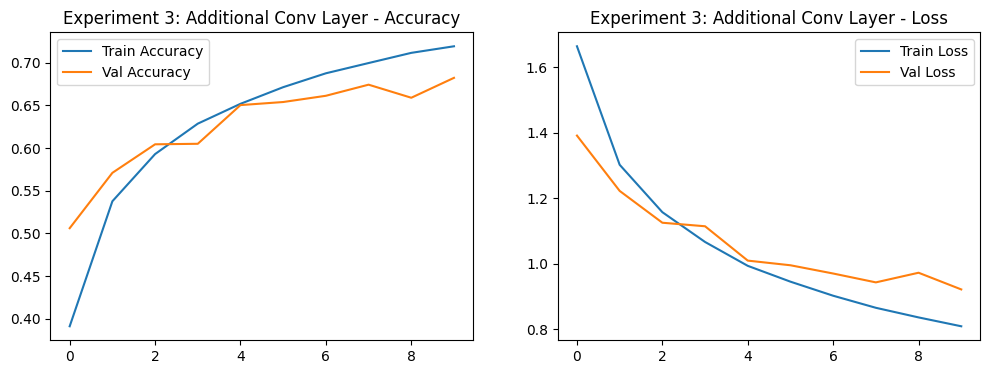

In [ ]:
exp3_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

exp3_model.summary()
acc_exp3, time_exp3 = train_and_evaluate(exp3_model, "Experiment 3: Additional Conv Layer")

### Експеримент 4: Функція LeakyReLU та нормалізація BatchNormalization

/home/stella/.pyenv/versions/3.9.13/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,946 (656.04 KB)

 Trainable params: 167,754 (655.29 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
  1/625 ━━━━━━━━━━━━━━━━━━━━ 42:07 4s/step - accuracy: 0.0781 - loss: 3.3705

E0000 00:00:1777912615.367342   67800 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/sequential_8_1/leaky_re_lu_3_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/sequential_8_1/conv2d_12_1/BiasAdd'.


625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3508 - loss: 1.8413 - val_accuracy: 0.5211 - val_loss: 1.3645
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.5454 - loss: 1.2873 - val_accuracy: 0.5465 - val_loss: 1.3479
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.6096 - loss: 1.1102 - val_accuracy: 0.5448 - val_loss: 1.2873
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.6463 - loss: 1.0006 - val_accuracy: 0.6073 - val_loss: 1.0976
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.6718 - loss: 0.9314 - val_accuracy: 0.5623 - val_loss: 1.2978
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.6960 - loss: 0.8584 - val_accuracy: 0.6281 - val_loss: 1.1577
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7182 - loss: 0.7879 - val_accuracy: 0.6742 - val_loss: 0.9727
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7377 - loss: 0.7424 - val_accurac

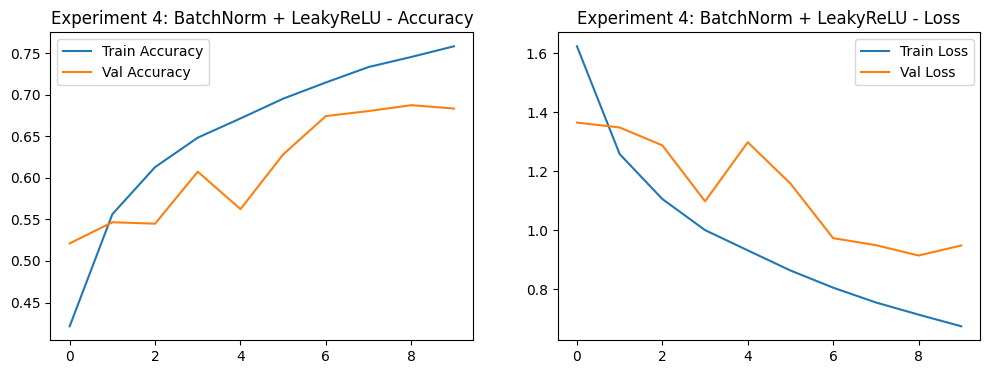

In [ ]:
exp4_model = Sequential([
    Conv2D(32, (3, 3), input_shape=(32, 32, 3)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

exp4_model.summary()
acc_exp4, time_exp4 = train_and_evaluate(exp4_model, "Experiment 4: BatchNorm + LeakyReLU")

### Результати

In [19]:
results = {
    "Model": ["Baseline", "Exp 1: 64 Filters", "Exp 2: Dropout", "Exp 3: Deeper CNN", "Exp 4: Complex"],
    "Test Accuracy (%)": [acc_base*100, acc_exp1*100, acc_exp2*100, acc_exp3*100, acc_exp4*100],
    "Training Time (sec)": [time_base, time_exp1, time_exp2, time_exp3, time_exp4]
}

results_df = pd.DataFrame(results)
print("=== Зведені результати експериментів ===")
display(results_df)

=== Зведені результати експериментів ===


,Model,Test Accuracy (%),Training Time (sec)
0,Baseline,62.930000,126.255123
1,Exp 1: 64 Filters,64.179999,224.324198
2,Exp 2: Dropout,55.479997,130.227571
3,Exp 3: Deeper CNN,68.199998,200.812222
4,Exp 4: Complex,68.709999,394.496228
